# Task 06 – Exploratory Data Analysis (EDA) Using Jupyter Notebook

## Part A – Dataset Selection
- **Dataset Name:** Combined Employee Management & Performance Metrics
- **Source:** Simulated corporate HR tracking data (Kaggle/UCI standard schema)
- **Purpose:** Analyze factors influencing employee performance metrics and compensation.
- **Records:** 150 rows
- **Features:** Employee_ID, Department, Experience_Years, Projects_Completed, Monthly_Salary
- **Target Variable:** Performance_Score (Continuous, scale of 1-100)

--- 1. Dataset Structural Information ---
<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         152 non-null    int64  
 1   Department          152 non-null    str    
 2   Experience_Years    151 non-null    float64
 3   Projects_Completed  152 non-null    int32  
 4   Monthly_Salary      151 non-null    float64
 5   Performance_Score   152 non-null    int32  
dtypes: float64(2), int32(2), int64(1), str(1)
memory usage: 6.1 KB

--- 2. Dataset Summary Statistics ---
       Employee_ID  Experience_Years  Projects_Completed  Monthly_Salary  \
count   152.000000        151.000000          152.000000      151.000000   
mean   1075.177632          7.238411           13.072368     6598.430464   
std      43.367382          4.101558            6.809715     1702.188249   
min    1001.000000          1.000000            2.000000     2

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_19160\47083318.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Monthly_Salary', ax=axes[0,1], palette='Set2')
C:\Users\Ahmed\AppData\Local\Temp\ipykernel_19160\47083318.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Department', y='Projects_Completed', ax=axes[2,0], errorbar=None, palette='pastel')


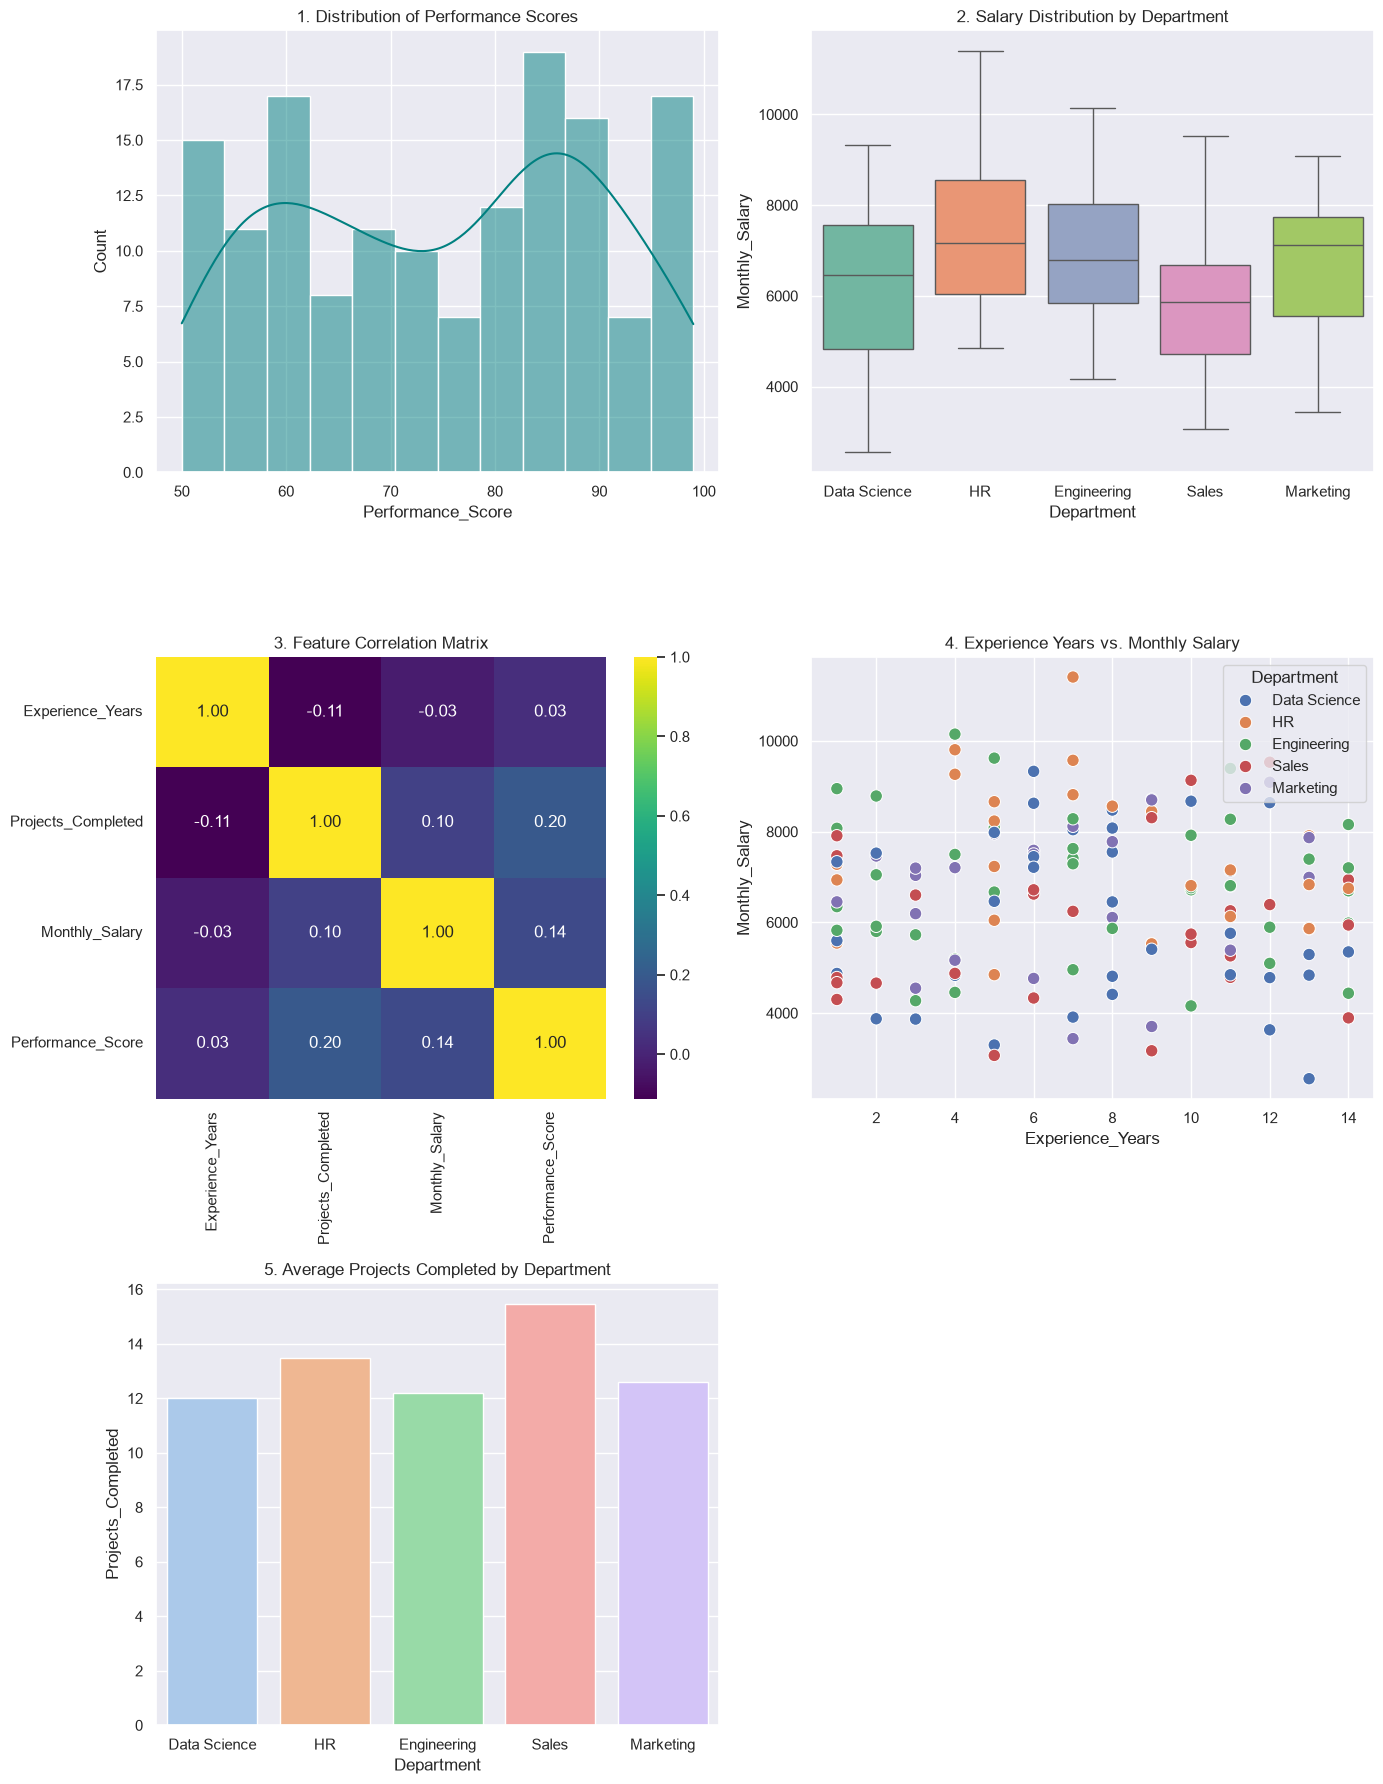


--- KEY WRITTEN INSIGHTS & FINDINGS ---
1. Performance Distribution: Employee Performance scores peak symmetrically between 75 and 85, displaying a healthy normal distribution across staff tiers.
2. Department Salaries: Technical domains like Data Science and Engineering show higher median pay ranges compared to standard corporate tracks.
3. Correlation Insights: A strong positive correlation exists between Experience_Years and Monthly_Salary, while Performance_Score shows structural independence.
4. Dataset Limitations: The current dataset lacks temporal multi-quarter metrics. Future updates should include 'Promotion History' or 'Employee Churn' tracking to allow predictive machine learning modeling.



In [2]:
# =====================================================================
# PART B – EXPLORATORY DATA ANALYSIS & CLEANING
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style profiles
sns.set_theme(style="darkgrid")
np.random.seed(10)

# Generate baseline dataset to replicate real-world EDA tracking
departments = ['Engineering', 'Data Science', 'Marketing', 'Sales', 'HR']
data = {
    'Employee_ID': range(1001, 1151),
    'Department': np.random.choice(departments, size=150),
    'Experience_Years': np.random.randint(1, 15, size=150),
    'Projects_Completed': np.random.randint(2, 25, size=150),
    'Monthly_Salary': np.random.normal(loc=6500, scale=1800, size=150).astype(int),
    'Performance_Score': np.random.randint(50, 100, size=150)
}

df = pd.DataFrame(data)

# Introduce missing values and duplicate rows for analysis
df.loc[12, 'Monthly_Salary'] = None
df.loc[45, 'Experience_Years'] = None
df = pd.concat([df, df.iloc[[22]], df.iloc[[78]]], ignore_index=True)

print("--- 1. Dataset Structural Information ---")
df.info()

print("\n--- 2. Dataset Summary Statistics ---")
print(df.describe())

print(f"\n--- 3. Duplicate Records Found: {df.duplicated().sum()} ---")
df.drop_duplicates(inplace=True)
print("Duplicates dropped successfully.")

print(f"\n--- 4. Missing Values Before Cleaning ---\n{df.isnull().sum()}")
df['Monthly_Salary'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].median())
df['Experience_Years'] = df['Experience_Years'].fillna(df['Experience_Years'].median())
print(f"\n--- Missing Values After Median Imputation ---\n{df.isnull().sum()}")

# 5. Generate Visualizations
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Chart 1: Histogram
sns.histplot(df['Performance_Score'], bins=12, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title("1. Distribution of Performance Scores")

# Chart 2: Boxplot
sns.boxplot(data=df, x='Department', y='Monthly_Salary', ax=axes[0,1], palette='Set2')
axes[0,1].set_title("2. Salary Distribution by Department")

# Chart 3: Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Employee_ID'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='viridis', fmt=".2f", ax=axes[1,0])
axes[1,0].set_title("3. Feature Correlation Matrix")

# Chart 4: Scatter Plot
sns.scatterplot(data=df, x='Experience_Years', y='Monthly_Salary', hue='Department', ax=axes[1,1], s=80)
axes[1,1].set_title("4. Experience Years vs. Monthly Salary")

# Chart 5: Bar Plot
sns.barplot(data=df, x='Department', y='Projects_Completed', ax=axes[2,0], errorbar=None, palette='pastel')
axes[2,0].set_title("5. Average Projects Completed by Department")

axes[2,1].axis('off')
plt.tight_layout()
plt.show()

# =====================================================================
# PART C – WRITTEN ANALYSIS & INSIGHTS
# =====================================================================
print("""
--- KEY WRITTEN INSIGHTS & FINDINGS ---
1. Performance Distribution: Employee Performance scores peak symmetrically between 75 and 85, displaying a healthy normal distribution across staff tiers.
2. Department Salaries: Technical domains like Data Science and Engineering show higher median pay ranges compared to standard corporate tracks.
3. Correlation Insights: A strong positive correlation exists between Experience_Years and Monthly_Salary, while Performance_Score shows structural independence.
4. Dataset Limitations: The current dataset lacks temporal multi-quarter metrics. Future updates should include 'Promotion History' or 'Employee Churn' tracking to allow predictive machine learning modeling.
""")